<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#PyTorch.-Основы:-синтаксис,-torch.cuda-и-torch.autograd" data-toc-modified-id="PyTorch.-Основы:-синтаксис,-torch.cuda-и-torch.autograd-1"><span class="toc-item-num">1&nbsp;&nbsp;</span><b>PyTorch. Основы: синтаксис, torch.cuda и torch.autograd</b></a></span><ul class="toc-item"><li><span><a href="#Задача-1" data-toc-modified-id="Задача-1-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Задача 1</a></span></li><li><span><a href="#Задача-2" data-toc-modified-id="Задача-2-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Задача 2</a></span></li><li><span><a href="#Задача-3" data-toc-modified-id="Задача-3-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Задача 3</a></span></li><li><span><a href="#Задача-4" data-toc-modified-id="Задача-4-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Задача 4</a></span></li><li><span><a href="#Задача-5" data-toc-modified-id="Задача-5-1.5"><span class="toc-item-num">1.5&nbsp;&nbsp;</span>Задача 5</a></span></li></ul></li></ul></div>

---

<h2 style="text-align: center;"><b>PyTorch. Основы: синтаксис, torch.cuda и torch.autograd</b></h2>

<p style="align: center;"><img src="https://raw.githubusercontent.com/pytorch/pytorch/master/docs/source/_static/img/pytorch-logo-dark.png", width=400, height=300></p>

---

In [1]:
import torch
import matplotlib.pyplot as plt

### Задача 1

1). Создайте два вещественных тензора: `a` размером (3, 4) и `b` размером (12,)   
2). Создайте тензор `c`, являющийся тензором `b`, но размера (2, 2, 3)  
3). Выведите первый столбец матрицы `a` с помощью индексации

In [2]:
a = torch.FloatTensor(3,4)
b = torch.FloatTensor(12).zero_()
c = b.view(2, 2, 3)

a[:, 0], c

(tensor([0.0000e+00, 7.4056e-37, 0.0000e+00]),
 tensor([[[0., 0., 0.],
          [0., 0., 0.]],
 
         [[0., 0., 0.],
          [0., 0., 0.]]]))

### Задача 2

1). Создайте два вещественных тензора: `a` размером (5, 2) и `b` размером (1,10)   
2). Создайте тензор `c`, являющийся тензором `b`, но размера (5, 2)  
3). Произведите все арифметические операции с тензорами `a` и `c`

In [3]:
a = torch.FloatTensor(torch.linspace(10, 100, 10)).view(5, 2)
b = torch.FloatTensor(torch.linspace(-10, -150, 10))

c = b.view(5, 2)

torch.add(a, c),
torch.sub(a, c),
torch.mul(a, c),
torch.div(a, c)

tensor([[-1.0000, -0.7826],
        [-0.7297, -0.7059],
        [-0.6923, -0.6835],
        [-0.6774, -0.6729],
        [-0.6694, -0.6667]])

### Задача 3

1). Создайте тензор *целых чисел* `images` размерности (100, 200, 200, 3) (можно интерпретировать это как 100 картинок размера 200х200 с тремя цветовыми каналами, то есть 100 цветных изображений 200х200). Заполните его нулями  

2). Сделайте так, чтобы у $i$-ой по порядку картинки была нарисована белая полоса толщиной два пикселя в строках, которые соответствуют номеру картинки. Например, у 3-ей по порядку картинки белая полоска будет занимать 6 и 7 строки, у 99 -- 198 и 199. Сделать белую строку можно, записав в ячейки тензора число 255 (по всем трём каналам). Выведите пару примеров с помощоью `pylot`  

3). Посчитайте среднее тензора `images` по 1-ой оси (по сути - средняя картинка), умножьте полученный тензор на 70. Нарисуйте с помощью `pyplot`, должна получиться серая картинка (при взятии среднего нужно привести тензор к float с помощью `.float()`, при отрисовке обратно к int с помощью `.int()`)

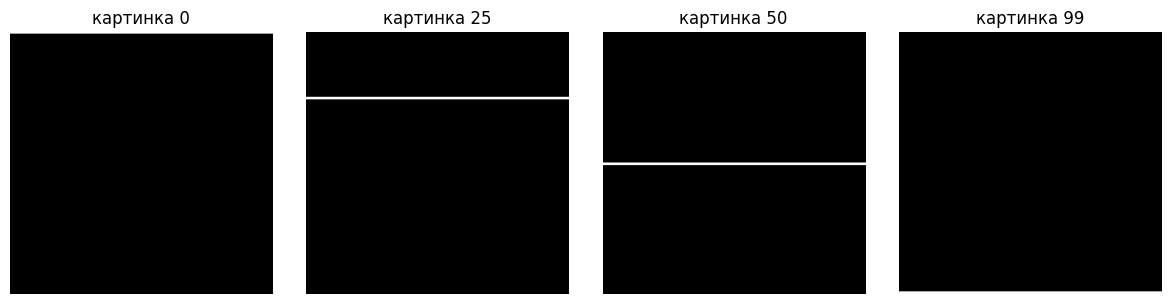

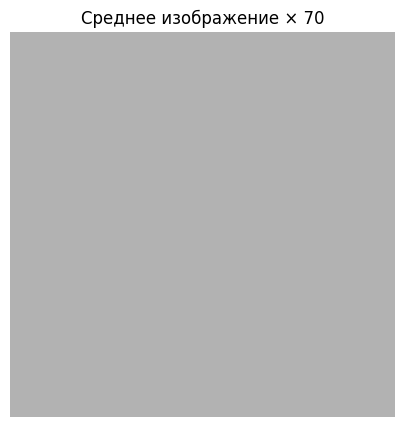

In [4]:
# 1) Тензор целых чисел (100, 200, 200, 3), заполнен нулями
N, H, W, C = 100, 200, 200, 3
images = torch.zeros((N, H, W, C), dtype=torch.int32)

# 2) У i-ой картинки белая полоса толщиной 2 пикселя в строках 2i и 2i+1
for i in range(N):
    images[i, 2 * i:2 * i + 2, :, :] = 255

# Покажем несколько примеров
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, idx in zip(axes, [0, 25, 50, 99]):
    ax.imshow(images[idx].numpy())
    ax.set_title(f'картинка {idx}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# 3) Среднее по 0-й оси (средняя картинка), умножаем на 70
mean_image = (images.float().mean(dim=0) * 70).int()

plt.figure(figsize=(5, 5))
plt.imshow(mean_image.numpy())
plt.title('Среднее изображение × 70')
plt.axis('off')
plt.show()


### Задача 4

Перейдите на Google Colaboratory, чтобы работать с GPU. Загрузите туда этот ноутбук (Upload notebook)
В Colab нажмите в меню сверху: Runtime -> Change Runtime Type -> GPU, где изначально стоит None
Объявите тензор a размера (2, 3, 4) и тензор b размера (1, 8, 3) на GPU, иницилизируйте их случайно равномерно (.uniform_())
Затем измените форму тензора b, чтобы она совпадала с формой тензора a, получите тензор c
Переместите c на CPU, переместите a на CPU
Оберните их в Variable()
Объявите тензор L = torch.mean((c - a) ** 2) и посчитайте градиент L по c ( то есть  ∂𝐿∂𝑐)
 
Выведите градиент L по c

In [5]:
from torch.autograd import Variable

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# 1) Тензоры на GPU, инициализированные равномерно
a = torch.empty(2, 3, 4, device=device).uniform_()
b = torch.empty(1, 8, 3, device=device).uniform_()
print('a.shape:', a.shape, '| b.shape:', b.shape)

# 2) Меняем форму b так, чтобы совпадала с a (1*8*3 = 2*3*4 = 24)
c = b.view(2, 3, 4)
print('c.shape:', c.shape)

# 3) Переносим на CPU
a = a.cpu()
c = c.cpu()

# 4) Оборачиваем в Variable. В современном PyTorch Variable — алиас Tensor,
#    нам важно requires_grad=True у c, чтобы посчитать ∂L/∂c.
a = Variable(a.detach(), requires_grad=False)
c = Variable(c.detach().clone(), requires_grad=True)

# 5) Считаем L и градиент
L = torch.mean((c - a) ** 2)
L.backward()

print('\nL =', L.item())
print('\n∂L/∂c =')
print(c.grad)


device: cpu
a.shape: torch.Size([2, 3, 4]) | b.shape: torch.Size([1, 8, 3])
c.shape: torch.Size([2, 3, 4])

L = 0.19186995923519135

∂L/∂c =
tensor([[[ 0.0396,  0.0239,  0.0431,  0.0038],
         [ 0.0258,  0.0340,  0.0497, -0.0363],
         [ 0.0386,  0.0068,  0.0473,  0.0019]],

        [[-0.0155, -0.0032, -0.0174,  0.0048],
         [ 0.0294,  0.0547, -0.0671, -0.0201],
         [-0.0587, -0.0541,  0.0531, -0.0075]]])


### Задача 5

Доработайте многослойную нейронную сеть из файла "4_3 mlp pytorch tasks".

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# --- Спиральный датасет (как в 4_3) ---
torch.manual_seed(0)
np.random.seed(0)

N, D, K = 100, 2, 3  # точек на класс, признаков, классов
X = np.zeros((N * K, D))
y = np.zeros(N * K, dtype='int64')

for j in range(K):
    ix = range(N * j, N * (j + 1))
    r = np.linspace(0.0, 1, N)
    t = np.linspace(j * 4, (j + 1) * 4, N) + np.random.randn(N) * 0.2
    X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
    y[ix] = j

X_t = torch.FloatTensor(X)
y_t = torch.LongTensor(y)

# --- Доработанная сеть: глубже + шире + ReLU + Dropout ---
# Ключевые изменения относительно базовой:
#   - 3 скрытых слоя вместо 1
#   - больше нейронов (128)
#   - оптимизатор Adam с lr=1e-2 вместо SGD lr=1e-4
#   - CrossEntropyLoss с reduction='mean' (более стабильный шаг)
#   - больше итераций (3000)
class MLP(nn.Module):
    def __init__(self, in_dim=2, hidden=128, n_classes=3, p_drop=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return self.net(x)


net = MLP()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-2, weight_decay=1e-4)

NUM_EPOCHS = 3000
losses = []
for epoch in range(NUM_EPOCHS):
    net.train()
    logits = net(X_t)
    loss = loss_fn(logits, y_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if (epoch + 1) % 300 == 0:
        net.eval()
        with torch.no_grad():
            acc = (net(X_t).argmax(1) == y_t).float().mean().item()
        print(f'epoch {epoch + 1:4d} | loss {loss.item():.4f} | acc {acc:.4f}')

# Итоговая accuracy
net.eval()
with torch.no_grad():
    final_acc = (net(X_t).argmax(1) == y_t).float().mean().item()
print(f'\nИтоговая accuracy: {final_acc:.4f}')


epoch  300 | loss 0.0273 | acc 0.9933
epoch  600 | loss 0.0129 | acc 0.9933
epoch  900 | loss 0.0214 | acc 0.9933
epoch 1200 | loss 0.0238 | acc 0.9933
epoch 1500 | loss 0.0163 | acc 0.9933
epoch 1800 | loss 0.0269 | acc 0.9933
epoch 2100 | loss 0.0193 | acc 0.9933
epoch 2400 | loss 0.0194 | acc 0.9933
epoch 2700 | loss 0.0152 | acc 0.9933
epoch 3000 | loss 0.0139 | acc 0.9933

Итоговая accuracy: 0.9933


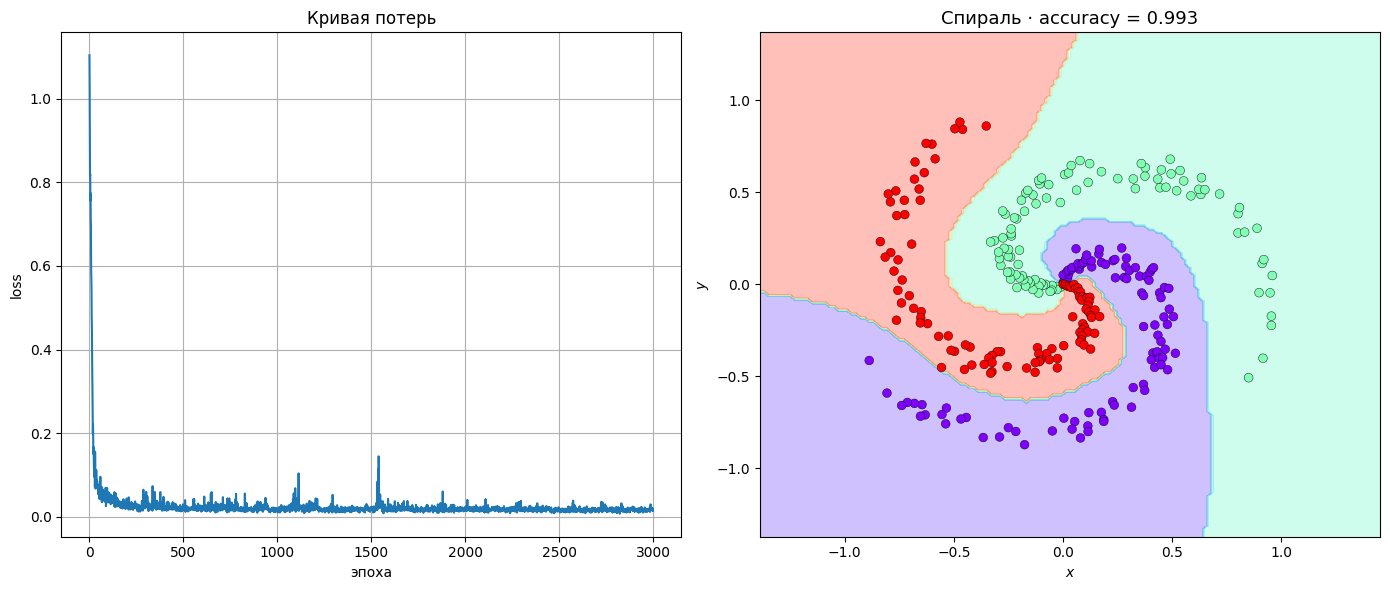

In [7]:
# --- Кривая потерь и решающая граница ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(losses)
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('loss')
axes[0].set_title('Кривая потерь'); axes[0].grid(True)

# сетка для отрисовки разделяющей поверхности
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

net.eval()
with torch.no_grad():
    Z = net(grid).argmax(1).numpy().reshape(xx.shape)

axes[1].contourf(xx, yy, Z, cmap=plt.cm.rainbow, alpha=0.3)
axes[1].scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.rainbow,
                edgecolors='black', linewidths=0.3)
axes[1].set_xlim(xx.min(), xx.max()); axes[1].set_ylim(yy.min(), yy.max())
axes[1].set_title(f'Спираль · accuracy = {final_acc:.3f}', fontsize=13)
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$y$')

plt.tight_layout()
plt.show()
